<a href="https://colab.research.google.com/github/Asertigi/statistic/blob/main/%D0%A1%D0%A3%D0%9D%D0%A6_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import shapiro
from scipy.stats import norm, uniform, ks_1samp, levene
from scipy.stats import ttest_ind, f_oneway

Файлы с данными лежат в папке по ссылке: https://drive.google.com/drive/folders/1N7M_yhakFID7gfPpBNmxPe1n1Aiy1rg2?usp=sharing

## Проверка нормальности
### Задание 1
Сгенерируйте два набора данных по 40 наблюдений:
- Первый набор из нормального распределения N(2, 3)
- Второй набор из равномерного распределения U(0, 10)

С помощью функции `shapiro` библиотеки `scipy` выполните проверку нормальности для каждого набора данных. Проинтерпретируйте полученные результаты.

In [111]:
n_d = np.random.normal(loc=2, scale=np.sqrt(3), size=40)
u_d = np.random.uniform(low=0, high=10, size=40)

norm = shapiro(n_d)
uni = shapiro(u_d)
print(f"Нормальное распределение: Statistic = {norm.statistic:.4f}, pvalue = {norm.pvalue:.4f}")
print(f"Равномерное распределение: Statistic = {uni.statistic:.4f}, pvalue = {uni.pvalue:.4f}")

if norm.pvalue > 0.05:
    print("Данные из нормального распределения являются нормальными.")
else:
    print("Данные из нормального распределения НЕ являются нормальными.")

if uni.pvalue > 0.05:
    print("Данные из равномерного распределения являются нормальными.")
else:
    print("Данные из равномерного распределения НЕ являются нормальными.")

Нормальное распределение: Statistic = 0.9716, pvalue = 0.4031
Равномерное распределение: Statistic = 0.9127, pvalue = 0.0046
Данные из нормального распределения являются нормальными.
Данные из равномерного распределения НЕ являются нормальными.


### Задание 2

Загрузите данные из файла `Предел текучести.xlsx`. Файл содержит замеры предела текучести для стали марки 09ГСФ при низком и высоком содержании ванадия.

Можно ли считать данные в каждом из двух наборов нормально распределёнными?  


In [112]:
f = open("Предел текучести.txt")
_ = f.readline()
lowArray = []
highArray = []
for s in f:
  ns = s.replace(',', '.')
  ns = ns.split('\t')
  ns = list(map(float, ns))
  lowArray.append(ns[0])
  highArray.append(ns[1])
low = shapiro(lowArray)
high = shapiro(highArray)
print(f"Statistic: {low.statistic}, pvalue: {low.pvalue}")
if low.pvalue > 0.05:
    print("Данные с низким содержанием являются нормальными.")
else:
    print("Данные с низким содержанием НЕ являются нормальными.")

print('\n', f"Statistic: {high.statistic}, pvalue: {high.pvalue}")
if high.pvalue > 0.05:
    print("Данные с высоким содержанием являются нормальными.")
else:
    print("Данные с высоким содержанием НЕ являются нормальными.")


Statistic: 0.9885633669262366, pvalue: 0.9070115996543543
Данные с низким содержанием являются нормальными.

 Statistic: 0.9647343609263991, pvalue: 0.1403040598401531
Данные с высоким содержанием являются нормальными.


## Подгонка распределений
### Задание 3

С помощью классов `norm` и `uniform` из `scipy.stats` осуществите подгонку двух этих распределений под данные с высоким содержанием ванадия. С помощью `ks_1samp` проведите тест Колмогорова-Смирнова для оценки точности подгонки. Какое из распределений удалось подогнать лучше?

Нормальное mu=454.63, sigma=15.36483322395658
Равномерное a=424.0, b=70.0
Тест Колмогорова-Смирнова (норм.) Statistic=0.12297458336139966, pvalue=0.40348287489497103
Тест Колмогорова-Смирнова (равн.) Statistic=0.2242857142857143, pvalue=0.010849882615900253
Данные могут быть из нормального распределения
Данные НЕ могут быть из равномерного распределения


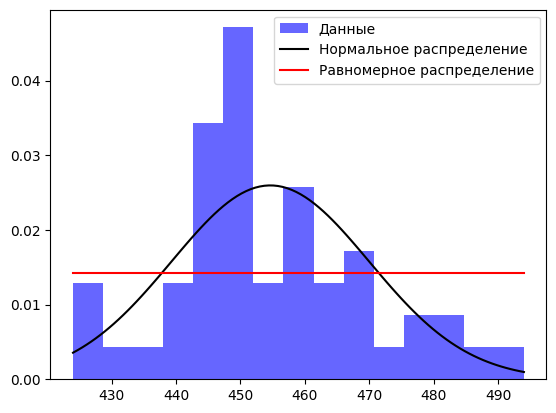

In [113]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, uniform, ks_1samp
#Подгонка
pn = norm.fit(highArray)
print(f"Нормальное mu={pn[0]}, sigma={pn[1]}")

pu = uniform.fit(highArray)
print(f"Равномерное a={pu[0]}, b={pu[1]}")

#КС
normm= ks_1samp(highArray, norm.cdf, args=pn)
print(f"Тест Колмогорова-Смирнова (норм.) Statistic={normm.statistic}, pvalue={normm.pvalue}")

unii = ks_1samp(highArray, uniform.cdf, args=pu)
print(f"Тест Колмогорова-Смирнова (равн.) Statistic={unii.statistic}, pvalue={unii.pvalue}")

if normm.pvalue > 0.05:
    print("Данные могут быть из нормального распределения")
else:
    print("Данные НЕ могут быть из нормального распределения")

if unii.pvalue > 0.05:
    print("Данные могут быть из равномерного распределения")
else:
    print("Данные НЕ могут быть из равномерного распределения")

x = np.linspace(min(highArray), max(highArray), 100)
pdfn = norm.pdf(x, *pn)
pdfu = uniform.pdf(x, *pu)

plt.hist(highArray, bins=15, density=True, alpha=0.6, color='blue', label='Данные')
plt.plot(x, pdfn, 'black', label='Нормальное распределение')
plt.plot(x, pdfu, 'red', label='Равномерное распределение')
plt.legend()
plt.show()

## Т-критерий
### Задание 4
Для данных, рассмотренных на лекции, вычислите средние значения и оцените значимость различия между средними. Используйте `ttest_ind` из `scipy`.

In [114]:
example1 = pd.DataFrame({'Группа 1': [2, 3, 1],
                         'Группа 2': [6, 7, 5]})
m1 = example1['Группа 1'].mean()
m2 = example1['Группа 2'].mean()

print(f"Среднее значение1: {m1}")
print(f"Среднее значение2: {m2}")


t, p = ttest_ind(example1['Группа 1'], example1['Группа 2'])

print(f"t-статистика: {t}")
print(f"p-значение: {p}")


if p < 0.05:
    print("значимо")
else:
    print("незначимо")

Среднее значение1: 2.0
Среднее значение2: 6.0
t-статистика: -4.898979485566356
p-значение: 0.00804989310083772
значимо


Т-критерий Стьюдента помимо нормальности данных требует равенство дисперсий в группах. С помощью функции `levene` библиотеки `scipy` осуществите тест Левена для проверки равенства дисперсий для данных из задания 2 (прочность при разном содержании ванадия). Можно ли для них использовать Т-критерий Стьюдента?

Оцените значимость различия между средними. Можно ли считать, что добавка ванадия повышает прочность стали?

In [115]:
from scipy.stats import levene, ttest_ind

s, p_levene = levene(lowArray, highArray)
print(f"Статистика (Левен): {s}")
print(f"p-значение (Левен): {p_levene}")

if p_levene > 0.05:
    print("Диспресии равны, можно использовать Т критерий Стьюдента")
else:
    print("Диспресии не равны, нельзя использовать Т критерий Стбюдента")


Статистика (Левен): 0.1216652615865412
p-значение (Левен): 0.7279836307088486
Диспресии равны, можно использовать Т критерий Стьюдента


In [116]:
t, p_ttest = ttest_ind(lowArray, highArray)

print(f"t-статистика: {t}")
print(f"p-значение для Т критерия: {p_ttest}")

if p_ttest < 0.05:
    print("Различие значимо")
    print("Ванадий значимо влияет на прочность")
else:
    print("Различие незначимо")
    print("Ванадий незначительно влияет на прочность")


t-статистика: -2.2652770285980943
p-значение для Т критерия: 0.025696870047471156
Различие значимо
Ванадий значимо влияет на прочность


## Дисперсионный анализ


In [117]:
example2 = pd.DataFrame({'Группа': [1, 1, 1, 2, 2, 2],
                         'Значение': [2, 3, 1, 6, 7 ,5]})
g1 = example2[example2['Группа'] == 1]['Значение']
g2 = example2[example2['Группа'] == 2]['Значение']

st, p_val = f_oneway(g1, g2)

print(f"f-статистика: {st}")
print(f"p-значение: {p_val}", '\n')

if p_val < 0.05:
    print("Различие значимо.")
else:
    print("Различие не значимо.")

f-статистика: 24.0
p-значение: 0.008049893100837719 

Различие значимо.


### Задание 5
Библиотечная функция для дисперсионного анализа требует задать зависимую переменную и фактор в виде формулы типа `str`: `'Зависимая ~ C(Фактор)'`, где вместо слов "Зависимая" и "Фактор" должны стоять имена столбцов. Напишите функцию, которая будет формировать такую формулу.

In [118]:
def anova_formula(dependent: str, factor: str) -> str:
    return f"{dependent} ~ C({factor})"

anova_formula('Значение', 'Группа')

'Значение ~ C(Группа)'

Выполните код из следующих ячеек и проанализируйте результат.

In [119]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

def anova(df: pd.DataFrame,
          dependent: str,
          factor: str):

    formula = anova_formula(dependent, factor)
    model = ols(formula, data=df).fit()
    res = sm.stats.anova_lm(model, typ=2)

    return res

In [120]:
anova(example2, 'Значение', 'Группа')

,sum_sq,df,F,PR(>F)
C(Группа),24.0,1.0,24.0,0.00805
Residual,4.0,4.0,NaN,NaN


Большие знчения SS и f-статистики (24.0) указывают на значительный разброс между группами (больше, чем внутри групп).

Малое значение SS(внутр.) означает, что данные внутри групп близки к своим средним.

p-значение равно 0.00805, что меньше уровня значимости 0.05, а значит различия между группами значимы.

### Задание 6
Загрузите файл `Марки стали.xlsx` он содержит данные о прочности стали трёх марок. Выясните, есть ли значимое различие в прочности?

In [121]:
df = pd.read_excel("Марки стали.xlsx")
print(df['Марка'].unique())
df['Марка'] = df['Марка'].astype('category')
anova_result = anova(df, 'Предел_текучести', 'Марка')
print(anova_result, '\n')

if anova_result["PR(>F)"].iloc[0] < 0.05:
    print("Да")
else:
    print("Нет")

['СТ3СП' '09ГСФ' 'С345']
                sum_sq    df           F        PR(>F)
C(Марка)  93957.266667   2.0  402.661217  7.933671e-21
Residual   3150.100000  27.0         NaN           NaN 

Да


Данные удобно отображать на графике средних с ошибками.

In [122]:
def means_plot(df, value_var, group_var):
    grouped = df.groupby(by=group_var)
    means = grouped.mean()
    sigmas = grouped.std()

    plt.errorbar(means.index.astype(str), means[value_var],
                 yerr=sigmas[value_var],
                 fmt='-o',
                 capsize=3)
    plt.xlabel(group_var)
    plt.ylabel(value_var)
    plt.show()

<ipython-input-122-04b9a612fdbf>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(by=group_var)


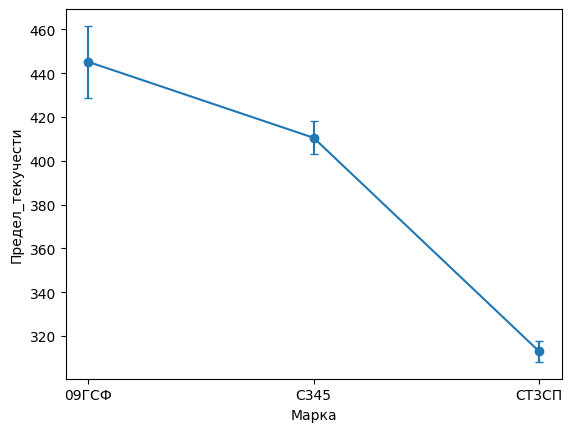

In [123]:
means_plot(df, 'Предел_текучести', 'Марка')

### Задание 7
Чтобы провести многофакторный дисперсионный анализ, нужно добавить в формулу все факторы, а также желаемые взаимодействия.
`Зависимая ~ C(A) + C(B) + C(A):C(B)`

Мы будем рассматривать два фактора, поэтому достаточно доработать функцию для формулы так, чтобы она добавляла их и их взаимодействие. Однако, вы можете реализовать функцию для общего случая, где в формуле может быть произвольное число факторов и всевозможные взаимодействия пар, троек и т.д.

Напишите функции для формулы и для дисперсионного анализа. Проведите анализ для приведённых примеров.

In [124]:
def anova_formula(dependent: str, factors: list) -> str:
    formula = dependent + " ~ " + " + ".join([f"C({factor})" for factor in factors])
    if len(factors) == 2:
        formula += " + C(" + factors[0] + ")*C(" + factors[1] + ")"

    return formula

def anova(df: pd.DataFrame, dependent: str, factors: list):
    formula = anova_formula(dependent, factors)
    model = ols(formula, data=df).fit()
    res = sm.stats.anova_lm(model, typ=2)
    return res

In [125]:
example3 = pd.DataFrame({'Пол': ['м'] * 6 + ['ж'] * 6,
                         'Группа': [1, 1, 1, 2, 2, 2] * 2,
                         'Значение': [2, 3, 1, 6, 7, 5, 4, 5, 3, 8, 9, 7]})

In [126]:
anova_result = anova(example3, 'Значение', ['Пол', 'Группа'])

print(anova_result)

if anova_result["PR(>F)"].iloc[0] < 0.05:
    print("Существует различие по полу.")
if anova_result["PR(>F)"].iloc[1] < 0.05:
    print("Существует различие по группам.")
if anova_result["PR(>F)"].iloc[2] < 0.05:
    print("Существует взаимодействие между полом и группой.")

                        sum_sq   df             F    PR(>F)
C(Пол)            1.200000e+01  1.0  1.200000e+01  0.008516
C(Группа)         4.800000e+01  1.0  4.800000e+01  0.000121
C(Пол):C(Группа)  5.339602e-29  1.0  5.339602e-29  1.000000
Residual          8.000000e+00  8.0           NaN       NaN
Существует различие по полу.
Существует различие по группам.


In [127]:
example4 = pd.DataFrame({'Пол': ['м'] * 6 + ['ж'] * 6,
                         'Группа': [1, 1, 1, 2, 2, 2] * 2,
                         'Значение': [10, 12, 8, 5, 7, 3, 5, 7, 3, 10, 12, 8]})

### Задание 8
Загрузите файл `Электропроводность.xlsx`. Изучите зависимость электропроводности алюминия от его чистоты и температуры окружающей среды.

In [128]:
f = open("Электропроводность.txt")
s = f.readline()
s = s.split('\t')
a = [[] for _ in range(3)]
s[2] = s[2][:-1]
for i in f:
    j = i
    j = j.replace(',', '.')
    j = j.split('\t')
    a[0].append(int(j[0]))
    a[1].append(j[1])
    a[2].append(float(j[2]))
print(s[0], s[1], s[2])
data = {
    s[0]: a[0],
    s[1]: a[1],
    s[2]: a[2]
}
df = pd.DataFrame(data)
df['clear'] = df['clear'].map({'высокая': 1, 'низкая': 0})

model = ols('electr ~ temp + clear + temp:clear', data=df).fit()
anova_result = sm.stats.anova_lm(model, typ=2)
print(anova_result)

if anova_result["PR(>F)"].iloc[0] < 0.05:
    print("Есть различия по температуре")
else:
    print("Различий по температуре нет.")

if anova_result["PR(>F)"].iloc[1] < 0.05:
    print("Есть различия по чистоте алюминия")
else:
    print("Различий по чистоте алюминия нет.")

if anova_result["PR(>F)"].iloc[2] < 0.05:
    print("Взаимодействие между температурой и чистотой алюминия значимо.")
else:
    print("Взаимодействие между температурой и чистотой алюминия незначимо.")

temp clear electr
              sum_sq    df           F        PR(>F)
temp        1.404500   1.0  181.076033  3.178171e-13
clear       0.341333   1.0   44.006612  4.899819e-07
temp:clear  0.004500   1.0    0.580165  4.531017e-01
Residual    0.201667  26.0         NaN           NaN
Есть различия по температуре
Есть различия по чистоте алюминия
Взаимодействие между температурой и чистотой алюминия незначимо.
